# Matmul to silicon 7c: SIMT, tiles, and occupancy

> **Module thesis:** a GPU is not built to make one thread fast — it is built to
> never have an idle ALU. This part is where the descent reaches the warp itself.

In [7a](Lecture7a.md) one line of PyTorch became a kernel launch; in
[7b](Lecture7b.md) we met the throughput machine that runs it — thousands of
resident threads, and a scheduler that runs somebody else whenever one warp
stalls. This part looks at the shape of that thread army: the warp and the price
of lockstep *(Depth 4)*, the tile of `C` each block owns — which finally decodes
the kernel name from 7a *(Depth 5)* — and occupancy, the budget residency lives
on. It closes with the synthesis, the capstone, and the appendices and
references for all of Lecture 7.

Every measurement on this page was produced by a cell you can re-run on your own
GPU. If you do not have one, open the same page as a notebook on a free Colab T4:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ankush-Chander/DS635-ml-system-engineering/blob/main/docs/lectures/Lecture7c.ipynb)

On Colab, pick **Runtime → Change runtime type → T4 GPU** first, then run the
cell below once. It installs only what is missing, so it is a no-op on a machine
that already has everything.

In [1]:
# Setup. Safe to re-run: nothing is installed if it is already importable.
import importlib.util, subprocess, sys

def ensure(module, spec=None):
    """Install `spec` only if `module` cannot already be imported."""
    if importlib.util.find_spec(module) is not None:
        return
    for candidate in ([spec, module] if spec and spec != module else [module]):
        print(f"installing {candidate} ...")
        if subprocess.run([sys.executable, "-m", "pip", "install", "-q", candidate]).returncode == 0:
            return
    raise RuntimeError(f"could not install {module}")

def triton_spec():
    """The exact Triton this torch build was compiled against.

    Torch declares Triton as a dependency, so we can read the pin instead of
    guessing. A mismatched Triton imports fine and then fails at the first
    `@triton.jit` -- much harder to diagnose than a missing package.
    """
    try:
        from importlib.metadata import requires
        for req in requires("torch") or []:
            dep = req.split(";")[0].strip()     # drop the environment marker
            if "triton" in dep:                 # `triton` on CUDA, `triton-rocm` on ROCm
                return dep
    except Exception:
        pass
    return "triton"

ensure("torch")                  # preinstalled on Colab; listed so the set is complete
ensure("matplotlib")
ensure("triton", triton_spec())

import torch, triton
print(f"torch {torch.__version__} | triton {triton.__version__} | cuda {torch.cuda.is_available()}")

torch 2.13.0+rocm7.2 | triton 3.7.1 | cuda True


In [2]:
# Re-establish the handles every cell below uses. Lecture 7a builds these up
# step by step; here they are just plumbing.
import torch, triton, triton.language as tl

assert torch.cuda.is_available(), "these cells need an NVIDIA or AMD GPU (or a free Colab T4)"
dev  = torch.cuda.get_device_properties(0)
WARP = getattr(dev, "warp_size", 32)
print(f"{dev.name} | {dev.multi_processor_count} units | warp {WARP} | torch {torch.__version__}")

AMD Radeon RX 6700M | 18 units | warp 32 | torch 2.13.0+rocm7.2


---

## Depth 4 — SIMT: the shape of the thread army

We have been saying "warp" for a while. Now we look at it directly, because it is
the level where the programming model and the hardware finally disagree.

The launch hierarchy maps onto physical hardware like this:

```text
SOFTWARE                         HARDWARE
grid   (all the threads)   ←→    the whole GPU (a work distributor hands out blocks)
block  (e.g. 128 threads)  ←→    ONE compute unit — never split, lives and dies there
warp   (32 threads)        ←→    one scheduler slot on that compute unit
thread                     ←→    one ALU lane
```

The block→CU pinning is what makes a block meaningful: threads in a block can
cooperate through shared memory and barriers precisely *because* they are
guaranteed to share one physical unit. Blocks cannot talk to each other — and that
independence is why the same code scales unchanged from an 18-unit laptop chip to
a 132-SM datacentre part.

> **The warp bargain.** The 32 threads of a warp share **one instruction
> fetch/decode unit**. Every cycle, all 32 lanes execute the same instruction on
> different data, in lockstep. Fetch and decode circuitry is expensive; paying for
> it once per 32 lanes is how the GPU affords thousands of ALUs. It is
> throughput-over-latency applied to the floor plan.

### Seeing the hierarchy instead of believing it

The table above is a claim. Make the GPU draw it for you.

The kernel below computes nothing useful. Every position simply writes down *who it
was* — which program owned it, which warp inside that program, which lane inside
that warp. Reshape the output into a rectangle and the execution hierarchy becomes
a picture.

One deliberate choice makes the picture honest. We saw that Triton normally picks
`num_warps` for you, and for `BLOCK = 64` it picks 4 — 128 hardware lanes for 64
elements. Under that mapping "which warp am I" would be a label we invented, not
something real. So we **pin** `num_warps = BLOCK // 32`, giving exactly one element
per hardware lane. Only then does `lane // 32` genuinely name the warp a value
lives in.

grid 16 programs x BLOCK 64 elements = 1024 elements, drawn as 16x64
num_warps pinned to 2: 64 lanes for 64 elements -> 1 element per lane


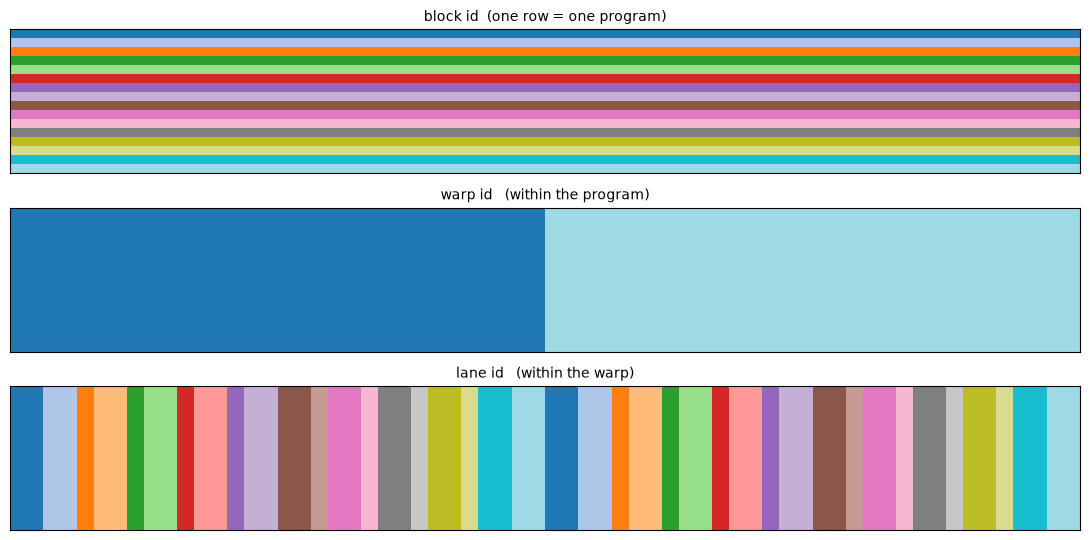

In [3]:
@triton.jit
def who_am_i(out_ptr, n, WHAT: tl.constexpr, BLOCK: tl.constexpr):
    # WHAT is tl.constexpr, so it is known at COMPILE time. Triton compiles a
    # separate kernel per value and the `if` below disappears entirely -- it is not
    # a branch the GPU evaluates, and it costs nothing at runtime. (Contrast this
    # with a branch on data, which is this section's closing subject.)
    pid  = tl.program_id(0)          # which program instance am I?
    lane = tl.arange(0, BLOCK)       # [0 .. BLOCK-1]: my positions
    offs = pid * BLOCK + lane        # the global elements I own

    if WHAT == 0:
        # `pid` is one scalar, but we must store BLOCK values. Adding a zero vector
        # broadcasts it: pid -> [pid, pid, ..., pid].
        v = pid + tl.zeros([BLOCK], tl.int32)
    elif WHAT == 1:
        v = lane // 32               # 0..31 -> 0, 32..63 -> 1 : which warp
    else:
        v = lane % 32                # 0..31, then 0..31 again : position in the warp

    tl.store(out_ptr + offs, v.to(tl.float32), mask=offs < n)

import matplotlib.pyplot as plt

# H rows x W columns, with BLOCK == W, so ONE IMAGE ROW IS EXACTLY ONE PROGRAM.
# That is the whole trick behind reading the picture.
H, W, BLOCK = 16, 64, 64
NUM_WARPS   = BLOCK // 32                          # pin it: 1 element per hardware lane
out  = torch.empty(H * W, device="cuda")
grid = (triton.cdiv(H * W, BLOCK),)                # 1024 / 64 = 16 program instances

print(f"grid {grid[0]} programs x BLOCK {BLOCK} elements"
      f" = {grid[0]*BLOCK} elements, drawn as {H}x{W}")
print(f"num_warps pinned to {NUM_WARPS}: {NUM_WARPS*32} lanes for {BLOCK} elements"
      f" -> {BLOCK//(NUM_WARPS*32)} element per lane")

fig, axes = plt.subplots(3, 1, figsize=(11, 5.5))
for ax, what, title in zip(axes, (0, 1, 2),
                           ("block id  (one row = one program)",
                            "warp id   (within the program)",
                            "lane id   (within the warp)")):
    who_am_i[grid](out, H * W, what, BLOCK=BLOCK, num_warps=NUM_WARPS)
    ax.imshow(out.reshape(H, W).cpu(), aspect="auto", cmap="tab20", interpolation="nearest")
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Read the three panels together. Each is the same 1,024 elements, labelled at a
different level:

* **block id** — sixteen solid horizontal bands, one per row. Each program owns one
  contiguous run of 64 elements. This is the grid.
* **warp id** — every band splits into two halves. `BLOCK = 64` at 32 lanes per warp
  is two warps, so the left half of every row is warp 0 and the right half warp 1.
* **lane id** — a 0…31 ramp that restarts halfway across every row. That restart is
  the warp boundary, and the period of the ramp is the warp width.

Stacked up, the machine your 16-program launch produced is:

```text
grid: 16 programs
 ├── program 0
 │     ├── warp 0 → lanes 0..31   → elements 0..31
 │     └── warp 1 → lanes 0..31   → elements 32..63
 ├── program 1  … same structure, elements 64..127
 └── … 14 more
```

Change `BLOCK` and re-run. The bands get wider or narrower and the number of warps
per row changes with them — but the lane ramp keeps its period of 32 whatever you
choose. **You pick the block size. You do not pick that number.**

!!! question "💬 The kernel contains an `if`. Divergence, below, will show that branches inside a warp can cost real time. Why is this one free?"

    ??? hint "Answer"
        Because `WHAT` is declared `tl.constexpr` — a **compile-time** constant. Triton
        compiles three separate kernels, one per value, and in each of them the `if` has
        already been resolved and removed. No branch survives to run on the GPU. The
        expensive case below is the opposite: a branch on *data*, whose value
        differs between lanes of the same warp and therefore cannot be resolved until
        the kernel is executing.

### SIMT: SIMD with the vector hidden

An AVX2 instruction on a CPU operates on eight float lanes at once:

```text
one instruction
      │
      ▼
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ f32 │ f32 │ f32 │ f32 │ f32 │ f32 │ f32 │ f32 │
└─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┘
```

You explicitly program vectors, or rely on the compiler to generate them.

GPU programming hides the vector. You write scalar code:

```text
thread 0: C[0] = A[0] + B[0]
thread 1: C[1] = A[1] + B[1]
thread 2: C[2] = A[2] + B[2]
...
```

The hardware groups the threads:

```text
32 threads
      │
      ▼
one instruction
      │
      ▼
32 lanes execute together
```

This is **SIMT — Single Instruction, Multiple Threads**. The programming interface
looks like independent scalar threads. The hardware executes them in groups.

> **SIMT is SIMD with the vector hidden.**

That gap between the programming model and the hardware is responsible for several
important GPU performance effects — and for the correction that follows.

### A CUDA core is not a core

"2,304 cores" invites a misleading picture:

```text
2,304 tiny CPUs
```

That is not what the GPU contains. There are compute units that contain scheduling
and control machinery, and thousands of arithmetic lanes that those units drive.

A CUDA core / shader ALU is therefore better thought of as:

> **one arithmetic lane, not one independent processor.**

It has no independent program counter and cannot fetch and execute an independent
program. Prefer `2,304 FP32 ALUs` over `2,304 cores` when describing what the
silicon actually contains.

!!! question "💬 If a CUDA core is not a core, what *is* the smallest thing on a GPU that has its own program counter?"

    ??? hint "Answer"
        The **warp**, not the thread and certainly not the lane. A warp has one instruction stream and one program counter shared by its 32 lanes. That single fact is the source of both of the effects in this lecture: divergence (when lanes disagree about where the program counter should go) and the cheapness of warp switching (when the scheduler picks a different warp's program counter).

### Measure the warp width instead of looking it up

You can ask the driver for the warp size — `torch.cuda.get_device_properties(0).warp_size`.
That is looking up the answer. You can also make the hardware confess it.

Give each block exactly **one warp** (`num_warps=1`) and then vary how many
elements that block is asked to process. If threads were independent, halving the
block size should halve the work per block and cost half the time. If the hardware
really issues in groups of 32, then any block with 32 or fewer elements occupies a
whole warp anyway — and the unused lanes cost nothing, because they were never
free to begin with.

In [4]:
@triton.jit
def fixed_work(x_ptr, o_ptr, n, BLOCK: tl.constexpr, ITERS: tl.constexpr):
    offs = tl.program_id(0) * BLOCK + tl.arange(0, BLOCK)
    m = offs < n
    y = tl.load(x_ptr + offs, mask=m, other=0.0)
    for _ in range(ITERS):
        y = tl.maximum(y * 1.0000001 + 1.0, 0.0) * 0.9999   # not an affine recurrence:
    tl.store(o_ptr + offs, y, mask=m)                        # the compiler cannot close-form it

n = 1 << 18
x = torch.randn(n, device="cuda"); o = torch.empty_like(x)

print(f"{'BLOCK':>7} {'blocks':>8} {'ms':>9} {'Melem/s':>10} {'speedup':>9}")
base = None
for blk in (1, 2, 4, 8, 16, 32, 64, 128):          # not `B` -- that is one of our matrices
    g = (triton.cdiv(n, blk),)
    ms = triton.testing.do_bench(
        lambda: fixed_work[g](x, o, n, BLOCK=blk, ITERS=256, num_warps=1),
        warmup=25, rep=200, return_mode="median")
    thr = n / (ms * 1e-3) / 1e6
    base = base or thr
    print(f"{blk:>7} {g[0]:>8} {ms:>9.3f} {thr:>10.1f} {thr/base:>8.1f}x")

  BLOCK   blocks        ms    Melem/s   speedup
      1   262144     1.237      212.0      1.0x


      2   131072     0.661      396.5      1.9x


      4    65536     0.342      765.4      3.6x


      8    32768     0.187     1404.5      6.6x


     16    16384     0.101     2604.7     12.3x


     32     8192     0.055     4762.7     22.5x
     64     4096     0.056     4694.4     22.1x


    128     2048     0.055     4736.8     22.3x


Measured on the course laptop (RX 6700M, wave32, ROCm 7.2, Triton 3.7.1):

```text
BLOCK   blocks        ms    Melem/s   speedup
      1   262144     1.309      200.2      1.0x
      2   131072     0.652      402.2      2.0x
      4    65536     0.321      815.6      4.1x
      8    32768     0.166     1575.0      7.9x
     16    16384     0.092     2851.8     14.2x
     32     8192     0.052     5033.4     25.1x
     64     4096     0.052     5064.6     25.3x
    128     2048     0.052     5033.4     25.1x
```

Two regimes, and the boundary between them is the whole point.

Below 32, **each extra thread is free**: every doubling of `BLOCK` doubles the
throughput, because those lanes were sitting in the warp doing nothing. From 32
onward the throughput stops improving entirely — 32, 64 and 128 land within 1% of
each other — because the warp is now full and any further work has to be issued as
extra instructions.

> **The knee is the warp width. You just measured it without asking the vendor.**

!!! question "💬 A colleague launches blocks of 8 threads because their problem has 8 lanes of work and they want to 'use less of the GPU'. What fraction of the machine are they actually paying for?"

    ??? hint "Answer"
        **All of it.** A block of 8 threads still occupies a full 32-lane warp — the
        table shows a block of 8 running at 7.9× the throughput of a block of 1, while a
        block of 32 reaches 25.1×. They are being billed for 32 lanes and using 8. This
        is also why the wavefront width in [Appendix B](#appendix-b-this-laptops-gpus)
        matters: the same code on this laptop's integrated GPU is billed in units of 64.

### The price of SIMT: divergence

The warp bargain sends you a bill. Consider:

```cpp
if (x > 0)
    a();
else
    b();
```

Suppose exactly half of a 32-thread warp takes each branch. The hardware cannot
execute both paths simultaneously, because the warp shares one instruction stream
and one program counter. Instead:

```text
if (x[i] > 0) { A; } else { B; }        time →
  lanes with x>0 :  ██ A ██  ░░ idle ░░
  lanes with x≤0 :  ░░ idle ░░  ██ B ██     ← ½ speed here; 1/32 worst case
```

Both paths execute. Every lane is occupied during both passes, but half of the
lanes are inactive during each pass. This is **warp divergence**.

Matmul, incidentally, is beloved by the hardware partly because every thread runs
the identical multiply-add sequence — **zero divergence, ever**.

#### Divergence is per warp

Divergence is not determined by whether a branch exists. It depends on whether
threads **within the same warp** disagree. For example:

```cpp
if (tid < 32)
```

If the warp is aligned with those 32 threads, every thread in the warp agrees. No
divergence. But:

```cpp
if (tid % 2)
```

splits every warp into two groups, and both paths execute. Same branch syntax.
Very different hardware cost. The extreme case is a 32-way split:

```text
32 different paths
        ↓
32 sequential executions
```

#### But divergence does not automatically mean slower

!!! question "💬 A divergent kernel issues roughly twice the instructions of the non-divergent one. Predict the slowdown."

    ??? hint "Answer"
        **About 1.08×**, not 2×. Measured on the RX 6700M:

        ```text
        warp agrees, one path runs           :   1.200 ms
        warp splits on (lane % 2)            :   1.297 ms
        2x instructions, one dependent chain :   2.543 ms
        ```

        Doubling the instructions *along a dependent chain* costs 2.12×. Doubling them *across two independent paths* costs 1.08×. The instruction count is identical in both cases — so instruction count is not what you are being billed for.

The single-path kernel was a long dependent chain: each operation depended on the
result of the previous one, so many issue opportunities were already going unused.
The divergent kernel added another *independent* path, whose extra instructions
could occupy those otherwise-empty slots.

```text
single path:              divergent:
    useful instruction        path A instruction
    wait                      path B instruction
    useful instruction        path A instruction
    wait                      path B instruction
    ...                       ...
```

> **Divergence bills you in issue slots. Whether that costs you time depends on
> whether the machine had spare slots.**

Stated more generally, and worth carrying beyond GPUs:

> **Instruction count is not execution time.**

This is why "avoid all branches on GPUs" is bad advice. Measure the kernel.

---

## Depth 5 — One block, one tile of C

We can now cash in the kernel name from Depth 1 ([Lecture 7a](Lecture7a.md)).

Recall the naive kernel from Depth 2. Its last line was
`C[row*N + col] = sum`: each thread **owned one cell of the output** and computed
it end to end. Nothing about that changes in this depth except the *grain* of
ownership. The question a matmul decomposition answers is:

> **Who is responsible for writing which entries of the output `C`?**

We hand out the *answer*, not the inputs, for a reason. Every cell of `C` is an
independent dot product — no two blocks ever need to write the same cell. `A` and
`B`, by contrast, are read-only and shared: many blocks read the same row of `A`,
and that is fine, because reading is not a conflict. So the output is the natural
work list, and the inputs come along for the ride.

What "a tile of `C`" costs is then concrete. A block that owns a 128×64 patch of
the output must read the 128 rows of `A` and the 64 columns of `B` that feed it —
two strips, one patch:

```text
        A  (M×K)            B  (K×N)               C  (M×N)
   ┌──────────────┐    ┌───┬───┬───┬───┐     ┌───┬───┬───┬───┐
   │              │    │   │▒▒▒│   │   │     │   │   │   │   │
   ├──────────────┤    │   │▒▒▒│   │   │     ├───┼───┼───┼───┤
   │▒▒▒▒▒▒▒▒▒▒▒▒▒▒│ ×  │   │▒▒▒│   │   │  =  │   │███│   │   │  ← this block's
   ├──────────────┤    │   │▒▒▒│   │   │     ├───┼───┼───┼───┤     128×64 patch
   │              │    │   │▒▒▒│   │   │     │   │   │   │   │
   └──────────────┘    └───┴───┴───┴───┘     └───┴───┴───┴───┘
     128×K strip           K×64 strip          reads two strips, writes one patch
```

Why a *rectangle*, though, and not any 8,192 cells? Because sharing has a
geometry. `C[i,j]` needs row `i` of `A` and column `j` of `B`. Row `i` of `A` is
needed by every output in row `i` of `C`; column `j` of `B` by every output in
column `j`:

```text
                 column j of B is needed by
                 every output in THIS column
                        ↓
        ┌──────────────┬──────────────┐
        │              │ C[0,j]       │
        │              │ C[1,j]       │
row i → │ C[i,0] C[i,1]│ C[i,j] ...   │  ← row i of A is needed by
        │              │ C[3,j]       │    every output in THIS row
        └──────────────┴──────────────┘
```

Two outputs share input if they sit in the same row **or** the same column. The
set of outputs that maximises how many pairs share something is a rectangle: every
cell shares a row with its whole row and a column with its whole column. A
scattered bag of cells, or a long thin diagonal, shares almost nothing. Tiles are
rectangles because that is the shape of the dependency structure, not because of
convention.

Now the change of mental model has something to attach to:

> **Stop thinking "one thread = one cell of C". Think "one block = one patch of
> C, plus the two input strips that patch obligates it to read".**

That is not a stylistic preference. A block is pinned to one compute unit, which
is what makes its shared memory and barriers usable — so a block is the largest
group of threads that can *cooperate*: stage those two strips once, then have
every thread reuse them. Cutting `C` into patches and giving one block to each is
the decomposition the hardware is shaped for. (The vendor's name for a patch is a
**macro tile**; below the block there is a second, per-thread *micro-tile*, which
we meet when we decode the kernel name.)

C would be 512x512; tile 128x64 -> grid (4, 8) = 32 tiles


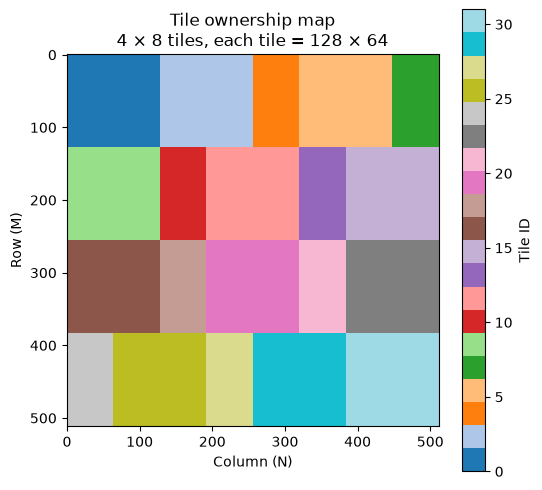

In [5]:
@triton.jit
def mark_tile_ownership(
    output_ptr,
    M, N,
    TILE_M: tl.constexpr,
    TILE_N: tl.constexpr,
):
    # Which tile is this GPU program responsible for?
    tile_row_id = tl.program_id(0)
    tile_col_id = tl.program_id(1)

    # Which matrix rows and columns belong to this tile?
    row_indices = tile_row_id * TILE_M + tl.arange(0, TILE_M)
    col_indices = tile_col_id * TILE_N + tl.arange(0, TILE_N)

    # Give this tile a unique ID.
    tiles_per_row = tl.cdiv(N, TILE_N)
    tile_id = tile_row_id * tiles_per_row + tile_col_id

    # Write the tile ID into every element of this tile.
    tl.store(
        output_ptr
        + row_indices[:, None] * N
        + col_indices[None, :],

        (tile_id + tl.zeros([TILE_M, TILE_N], tl.int32))
            .to(tl.float32),

        mask=(row_indices[:, None] < M)
           & (col_indices[None, :] < N),
    )


M = N = 512

TILE_M, TILE_N = 128, 64                      # the tile the library chose, below

tile_owners = torch.empty((M, N), device="cuda")   # C-shaped, but holds tile IDs, not A @ B

grid_shape = (
    triton.cdiv(M, TILE_M),
    triton.cdiv(N, TILE_N),
)

mark_tile_ownership[grid_shape](
    tile_owners,
    M, N,
    TILE_M=TILE_M,
    TILE_N=TILE_N,
)

print(
    f"C would be {M}x{N}; "
    f"tile {TILE_M}x{TILE_N} "
    f"-> grid {grid_shape} = "
    f"{grid_shape[0] * grid_shape[1]} tiles"
)

# Plot the tile ownership map.
plt.figure(figsize=(6, 6))

plt.imshow(
    tile_owners.cpu(),
    cmap="tab20",
    interpolation="nearest",
)

plt.title(
    f"Tile ownership map\n"
    f"{grid_shape[0]} × {grid_shape[1]} tiles, "
    f"each tile = {TILE_M} × {TILE_N}"
)

plt.xlabel("Column (N)")
plt.ylabel("Row (M)")

plt.colorbar(label="Tile ID")

plt.show()

`mark_tile_ownership` is `who_am_i` from Depth 4 in two dimensions. Everything
you already know carries over — `program_id`, `tl.arange`, the zero-vector
broadcast, the mask — and three lines are new. Read it against its 1-D twin:

| `who_am_i` (1-D, Depth 4) | `mark_tile_ownership` (2-D) | what changed |
| --- | --- | --- |
| `pid = program_id(0)` | `tile_row_id, tile_col_id = program_id(0), program_id(1)` | the grid is `(4, 8)`, so a program has a row-id **and** a column-id |
| `offs = pid * BLOCK + arange(BLOCK)` | `row_indices = tile_row_id * TILE_M + arange(TILE_M)` <br> `col_indices = tile_col_id * TILE_N + arange(TILE_N)` | the same formula, once per axis |
| `out_ptr + offs` | `output_ptr + row_indices[:, None] * N + col_indices[None, :]` | **new** — two 1-D ranges become a 2-D block of addresses |
| `v = pid + zeros([BLOCK])` | `tile_id = tile_row_id * tiles_per_row + tile_col_id` | **new** — the `(row, col)` id is linearised so the colours count 0 … 31 row-major |

Take the program at `(tile_row_id, tile_col_id) = (2, 5)`. Its rows are
`2 · 128 + [0 … 127] = 256 … 383`, its columns `5 · 64 + [0 … 63] = 320 … 383`,
and its id is `2 · 8 + 5 = 21`. It writes `21` into that 128×64 rectangle and
nothing else — the program was never *handed* a tile; it derived one from who it
is, exactly as in Depth 2.

The address line is the one that stops people. `row_indices[:, None]` is a
`128 × 1` column, `col_indices[None, :]` a `1 × 64` row; adding them broadcasts to
every `(row, col)` pair, and `* N` is plain row-major addressing,
`row · 512 + col`:

```text
                       col_indices[None, :]        (1 × 64)
                        320   321   322  …   383
                     ┌──────┬──────┬──────┬───────┐
row_indices  256  →  │256·N │256·N │256·N │       │
  [:, None]  257  →  │ +320 │ +321 │ +322 │  …    │   128 × 64 addresses,
  (128 × 1)  258  →  │  …   │      │      │       │   one per output the
             …       │      │      │      │       │   program owns
             383  →  │      │      │      │       │
                     └──────┴──────┴──────┴───────┘
```

The mask is all-true here because 512 divides by both 128 and 64. At 500×500
the last tile row would overhang by 12 rows (`cdiv` rounds up), and the mask is
what stops those writes.

That picture is the grid — a map of *who writes where*, not of what gets written. Now read the real one off the kernel name we captured
in [7a](Lecture7a.md) — it tells you the tile the vendor's library picked for
your matmul. This part is its own notebook, so first re-capture that name
(condensed from 7a's Depth 1, fallback included):

In [6]:
from torch.profiler import profile, ProfilerActivity

def gpu_kernel_name(fn, warmup=3):
    """Name of the GPU kernel `fn` spends the most DEVICE time in (see 7a)."""
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    with profile(activities=[ProfilerActivity.CUDA]) as prof:
        fn()
        torch.cuda.synchronize()
    on_device = [e for e in prof.key_averages() if e.self_device_time_total > 0]
    return max(on_device, key=lambda e: e.self_device_time_total).key if on_device else None

A = torch.randn(2048, 2048, device="cuda")
B = torch.randn(2048, 2048, device="cuda")
MATMUL_SHAPE = (A.shape[0], B.shape[1])

# Verbatim from a real run on the course laptop -- the stand-in for machines
# whose profiler cannot report kernel names (see 7a, Depth 1).
COURSE_LAPTOP_KERNEL = "Cijk_Ailk_Bljk_SB_MT128x64x8_SN_1LDSB0_..._TT8_8_..._WS32_WG16_8_1_WGM4"

MATMUL_KERNEL = gpu_kernel_name(lambda: A @ B) or COURSE_LAPTOP_KERNEL
print("decoding:\n", MATMUL_KERNEL)

decoding:
 Cijk_Ailk_Bljk_SB_MT128x64x8_SN_1LDSB0_APM1_ABV0_ACED0_AF0EM1_AF1EM1_AMAS3_ASE_ASGT_ASLT_ASM_ASAE01_ASCE01_ASEM1_AAC0_BL1_BS1_CLR0_DTLA0_DTLB0_DTVA0_DTVB0_DVO0_ETSP_EPS0_ELFLR0_EMLL0_FSSC10_FL0_GLVWA4_GLVWB4_GRCGA1_GRCGB1_GRPM1_GRVW4_GSU1_GSUASB_GLS0_ISA1030_IU1_K1_KLA_LBSPPA0_LBSPPB0_LPA0_LPB0_LDL1_LRVW4_LWPMn1_LDW0_FMA_MIAV0_MDA2_MO40_MMFGLC_MKFGSU256_NTA0_NTB0_NTC0_NTD0_NEPBS0_NLCA1_NLCB1_ONLL1_OPLV0_PK0_PAP0_PGR1_PLR1_PKA0_SIA1_SLW1_SS0_SU32_SUM3_SUS128_SCIUI1_SPO0_SRVW0_SSO0_SVW4_SNLL0_TSGRA0_TSGRB0_TT8_8_TLDS0_UMLDSA0_UMLDSB0_U64SL1_USFGROn1_VAW1_VSn1_VW4_VWB4_VFLRP0_WSGRA0_WSGRB0_WS32_WG16_8_1_WGM4.kd


USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:59] profiler_stop


Before handing it to code, read it token by token. Every field is vocabulary
from this lecture:

| Token | Meaning | Value here |
| --- | --- | --- |
| `Cijk_Ailk_Bljk` | Tensile index notation: `C[i,j] = Σₗ A[i,l]·B[l,j]` — a plain GEMM | — |
| `SB` | single precision (fp32), batched-capable | fp32 |
| `MT128x64x8` | **Macro Tile**: 128×64 of `C` per block; the `x8` is the depth of the K-slice per iteration | one patch = 8,192 outputs |
| `WG16_8_1` | **Workgroup** shape, 16×8×1 threads — the block | 128 threads → 4 warps |
| `TT8_8` | **Thread Tile**: 8×8 outputs per thread — the micro-tile | 64 outputs |
| `WS32` | **Wave Size** — the warp width you measured in Depth 4 | 32 lanes |

Now decode it:

In [7]:
import re

def decode(name, shape, warp=WARP, verbose=True):
    """Pull the decomposition out of a vendor GEMM kernel name.

    ROCm/Tensile spells it out: MT<m>x<n>x<k> macro tile, WG<x>_<y>_<z> workgroup,
    TT<m>_<n> per-thread tile, WS<w> wave size. cuBLAS is terser -- `sgemm_128x64`
    -- and gives only the tile. Anything else, we say so rather than guess.

    `shape` is the (M, N) of *this* matmul. The grid depends on it, so it is a
    parameter rather than a global -- the sweep further down decodes four shapes.
    """
    mt = re.search(r"MT(\d+)x(\d+)x(\d+)", name) or re.search(r"gemm_(\d+)x(\d+)", name)
    wg = re.search(r"WG(\d+)_(\d+)_(\d+)", name)
    tt = re.search(r"TT(\d+)_(\d+)", name)
    ws = re.search(r"WS(\d+)", name)
    if not mt:
        if verbose:
            print("could not find a tile shape in this kernel name -- print it and look yourself")
        return None
    bm, bn = int(mt.group(1)), int(mt.group(2))
    M, N = shape
    gm, gn = -(-M // bm), -(-N // bn)              # ceiling division
    w    = int(ws.group(1)) if ws else warp
    thr  = int(wg.group(1)) * int(wg.group(2)) * int(wg.group(3)) if wg else None
    tm, tn = (int(tt.group(1)), int(tt.group(2))) if tt else (None, None)
    if not verbose:                                # table mode, for the sweep below
        return {"tile": (bm, bn), "grid": (gm, gn), "threads": thr,
                "warps": thr // w if thr else None, "micro": (tm, tn)}
    print(f"tile of C per block   : {bm} x {bn}   = {bm*bn:,} outputs")
    print(f"grid                  : {gm} x {gn} = {gm*gn:,} blocks")
    if ws: print(f"wave size (hardware)  : {w}")
    if wg:
        print(f"threads per block     : {wg.group(1)}x{wg.group(2)}x{wg.group(3)} = {thr}"
              f"  -> {thr // w} warps per block")
        if tt:
            print(f"outputs per thread    : {tm} x {tn} = {tm*tn}")
            print(f"check                 : {thr} threads x {tm*tn} = {thr*tm*tn:,}"
                  f"  vs tile {bm*bn:,}  -> {'consistent' if thr*tm*tn == bm*bn else 'MISMATCH'}")

decode(MATMUL_KERNEL, MATMUL_SHAPE)

tile of C per block   : 128 x 64   = 8,192 outputs
grid                  : 16 x 32 = 512 blocks
wave size (hardware)  : 32
threads per block     : 16x8x1 = 128  -> 4 warps per block
outputs per thread    : 8 x 8 = 64
check                 : 128 threads x 64 = 8,192  vs tile 8,192  -> consistent


On the course laptop, for the 2048×2048 matmul at the top of this lecture:

```text
tile of C per block   : 128 x 64   = 8,192 outputs
grid                  : 16 x 32 = 512 blocks
wave size (hardware)  : 32
threads per block     : 16x8x1 = 128  -> 4 warps per block
outputs per thread    : 8 x 8 = 64
check                 : 128 threads x 64 = 8,192  vs tile 8,192  -> consistent
```

That is the complete answer to the question this lecture opened with. One line of
PyTorch became **512 blocks × 4 warps = 2,048 warps, 65,536 threads**, each thread
responsible for an 8×8 patch of `C`, and the arithmetic closes exactly.

Nothing here was a slide. Every one of those numbers came out of the string the
profiler printed for the line *you* wrote.

Notice the last two lines especially. Each thread does not compute one output — it
computes **64**, an 8×8 patch it keeps in registers. That is a second level of
tiling below the block, and it is the reason the register file has to be as large
as it is. Depth 3's budget and Depth 5's decomposition are the same constraint seen
from two ends.

The decode also lets you put a number on *why* the block bothers to own a patch
at all, rather than letting each thread fetch for itself.

!!! question "💬 The block owns 8,192 outputs and needs two strips of input. Count the floats that must come from DRAM with no sharing, then with sharing. What is the ratio?"

    ??? hint "Answer"
        | | floats from DRAM |
        | --- | --- |
        | no sharing — each of 128·64 threads fetches its own row of `A` and column of `B`, `2K` floats | `128 · 64 · 2K` |
        | sharing — the block fetches the two strips once, all 8,192 outputs compute from that copy | `(128 + 64) · K` |
        | ratio | `128·64·2 / (128+64) = 16,384 / 192` **≈ 85×** |

        Every float fetched is used about 85 times instead of once, and `K` cancels.
        The general form `2·BM·BN / (BM + BN)` is **area over perimeter**: the
        numerator counts outputs that benefit, the denominator counts what must be
        fetched. That is why it grows with the tile — 64×64 gives 64×, 128×128 gives
        128× — and why "fatter tiles, more reuse" is exact arithmetic, not a metaphor.

#### Does the shape change the tile?

That was one matmul. The library does not compute a tile from your dimensions —
it keeps a *catalogue* of pre-tuned kernels and picks one per problem. So put four
shapes through the same two functions and read the selections off. Nothing new is
defined here; `gpu_kernel_name` and `decode` are the ones above.

In [8]:
SHAPES = [
    (256,  256,  256),     # small -- is there even enough work to tile?
    (2048, 2048, 2048),     # the matmul this lecture opened with
    (2048, 8192,  512),     # wide N, shallow K
    (8192, 2048,  512),     # the row above with M and N swapped
]

print(f"{'M':>6} {'N':>6} {'K':>6} | {'macro tile':>12} {'grid':>11} "
      f"{'threads':>8} {'micro':>7} {'check':>11}")

for M, N, K in SHAPES:
    A = torch.randn(M, K, device="cuda")
    B = torch.randn(K, N, device="cuda")
    name = gpu_kernel_name(lambda: A @ B)
    del A, B; torch.cuda.empty_cache()          # 8192x2048 is 0.2 GB a side

    if name is None:
        # Deliberately NOT falling back to COURSE_LAPTOP_KERNEL here. One hardcoded
        # name would make every row identical -- a table "proving" the opposite of
        # the point. Say so instead, and read the recorded table below.
        print("\nthis machine's profiler does not report device kernel names;")
        print("the table printed below the cell is a verbatim course-laptop run.")
        break

    d = decode(name, (M, N), verbose=False)
    if d is None:
        print(f"{M:>6} {N:>6} {K:>6} | {name[:44]}  <- no tile field; print it and look")
        continue
    (bm, bn), (gm, gn), (tm, tn) = d["tile"], d["grid"], d["micro"]
    ok = d["threads"] and tm and d["threads"] * tm * tn == bm * bn
    print(f"{M:>6} {N:>6} {K:>6} | {f'{bm}x{bn}':>12} {f'{gm}x{gn}':>11} "
          f"{d['threads']:>8} {f'{tm}x{tn}':>7} {'consistent' if ok else 'MISMATCH':>11}")

     M      N      K |   macro tile        grid  threads   micro       check
   256    256    256 |        32x16        8x16      128     2x2  consistent
  2048   2048   2048 |       128x64       16x32      128     8x8  consistent
  2048   8192    512 |      128x128       16x64      128    8x16  consistent
  8192   2048    512 |       256x64       32x32      128    8x16  consistent


USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-08-31 10:28:22 35527:35527 SyncActivityProfilerHandler.cpp:59] profiler_stop


On the course laptop:

```text
     M      N      K |   macro tile        grid  threads   micro       check
   256    256    256 |        32x16        8x16      128     2x2  consistent
  2048   2048   2048 |       128x64       16x32      128     8x8  consistent
  2048   8192    512 |      128x128       16x64      128    8x16  consistent
  8192   2048    512 |       256x64       32x32      128    8x16  consistent
```

Four shapes, four different tiles — and three things worth stopping on.

**The block size never moved.** Every row is 128 threads, four warps. The library
does not vary how many threads it launches; it varies how much of `C` those 128
threads own, and pushes the difference into the micro-tile. A 32×16 macro tile
gives each thread 2×2 outputs; a 128×128 macro tile gives it 8×16. The macro tile
grew 32×, the block did not grow at all, and the check closes on every row.

**The small matmul got a tiny tile, and you can see why.** At 256×256 the library
picked 32×16 instead of the 128×64 it likes at 2048. Had it reused 128×64:

```text
grid = ceil(256/128) x ceil(256/64) = 2 x 4 = 8 blocks   on an 18-CU GPU
                                                          -> 10 units get nothing
```

Eight blocks cannot fill eighteen compute units. Shrinking the tile to 32×16 buys
128 blocks instead — worse reuse per block (the 85× above collapses toward 21×),
but every unit gets work. That is the same trade you measured in
[7b](Lecture7b.md): parallelism you cannot use is worthless, and here the library
is paying reuse to buy occupancy.

**Swapping `M` and `N` did not transpose the tile.** This is the one to sit with.
`2048×8192` selects a *square* 128×128 with a 16×8 workgroup; `8192×2048` — the
same problem, mirrored — selects a *long* 256×64 with a 32×4 workgroup. Not a
transpose, not even the same aspect ratio. The heuristic is not a formula being
applied to your dimensions; it is a lookup into what happened to be tuned, for
this architecture, this dtype, this library version.

So the honest chain is:

> **dimensions → kernel *selection* → tile configuration → work decomposition**
>
> not `dimensions → tile size`. Your dimensions are an *input to a heuristic*,
> alongside the architecture, the dtype and the library build. Change any of those
> and the table above changes with it — which is why it is a measurement you re-run,
> not a specification you can look up.

!!! tip "If the sweep prints nothing on ROCm"

    On this course laptop the PyTorch profiler reports only host-side HIP calls —
    `prof.key_averages()` comes back with `aten::mm` and `hipExtModuleLaunchKernel`
    and no device rows at all, so `gpu_kernel_name` returns `None`. The runtime will
    still tell you directly:

    ```bash
    AMD_LOG_LEVEL=3 python your_script.py 2>&1 | grep -oE "Cijk[A-Za-z0-9_]*" | sort -u
    ```

    That prints the full Tensile name, which you can paste straight into `decode`.
    The four names in the table above were captured exactly this way.

Back at the 2048² kernel, one field of its name is still unread: the trailing `x8`
in `MT128x64x8`. The two strips do not fit — the `A` strip alone is `128 · 2048`
floats, 1 MB, against 64 KB of LDS — so the block streams them in K-slices, 8
columns of `A` and 8 rows of `B`
at a time, `2048 / 8 = 256` steps. Slicing does not touch the 85×: each slice is
still shared by all 8,192 outputs. That loop, and what it buys against memory
bandwidth, is [Lecture 8](Lecture8.md).

---

## Occupancy: the budget on residency

Latency hiding needs resident warps. Resident warps consume resources. Occupancy
is the name of that trade.

The main budgets are registers, shared memory, maximum resident waves, maximum
threads, and architectural limits per block. They interact in one direction:

```text
more registers per thread          more shared memory per block
        ↓                                  ↓
fewer threads fit                  fewer blocks fit on a CU
        ↓                                  ↓
fewer resident warps               fewer resident warps
        ↓
fewer candidates for the scheduler
        ↓
less latency hiding
```

On this GPU:

```text
32 waves per CU
64 KB LDS per workgroup
```

A block requesting 32 KB of shared memory is therefore limited to `64 / 32 = 2`
blocks resident per CU, even if registers would allow more.

### Is low occupancy bad?

Suppose a profiler reports **25% occupancy**. Is that automatically a problem?

No. Occupancy is only one ingredient in latency hiding. The real goal is:

> **Have enough independent work in flight to cover the latency generated by this
> kernel.**

A kernel with high arithmetic intensity, lots of instruction-level parallelism and
many registers per thread may run very well at low occupancy. Reducing register
usage simply to raise occupancy can even make things worse, if it causes register
spills to memory.

> **Occupancy is a diagnostic to read when something is slow, not a score to
> maximize.**

This is also the trade-off that produced the hundreds of pre-compiled BLAS kernels
we met in Depth 1. Fatter tiles mean more reuse per byte fetched — the 85× of
Depth 5 grows with the tile — but fewer resident warps to hide latency with. They
compete for the same silicon, the best compromise depends on the shape, and so the
vendor ships one kernel per point on that curve and picks between them at call
time.

---

## What lies below

The descent has three depths left, and all of them are about *feeding* the machine
we just built. They are [Lecture 8](Lecture8.md):

* **Depth 6 — coalescing and broadcast.** DRAM cannot hand out single floats; it
  serves 128-byte lines. So the memory system inspects a warp's 32 lockstep
  addresses *as a group*. Neat and adjacent → one transaction. Scattered → up to 32
  transactions for the same instruction. This is the same warp we just met, seen
  from the memory side.
* **Depth 7 — the hierarchy and the FLOPs/byte wall.** Registers, shared memory,
  L2, DRAM. Arithmetic capacity has outgrown bandwidth so far that a modern GPU
  needs *hundreds* of floating-point operations per byte fetched to stay busy — and
  a naive matmul manages about one. Latency hiding cannot help here: it hides
  *latency*, not missing *bandwidth*. Tiling is what breaks that wall, and the
  85× you computed in Depth 5 is the tool.
* **Depth 8 — tensor cores and `torch.compile`.** Casting matmul into dedicated
  wiring, and removing the round-trips to slow memory between kernels.

One organizing principle sits underneath all three, and it is worth carrying out of
this lecture even before you meet the evidence:

> **Arithmetic is nearly free; moving data is expensive. Every layer of this stack
> is an arrangement for touching slow memory as rarely as possible** — coalescing
> per instruction, tiling per block, register micro-tiles per thread, fusion per
> graph.

---

## Synthesis: the whole descent

```text
C = A @ B
   │
   │  CPU-side, ~159 µs of paperwork (measured, Depth 1)
   │  dispatcher (keys: CUDA, fp32) → BLAS heuristic → kernel pick
   ▼
launch → command queue → doorbell (MMIO write) → CPU RETURNS
   │                              …async: the math has not happened yet
   ▼
the work distributor drops 512 blocks onto 18 units, in waves
   │
   ▼  on each compute unit:
block = one 128×64 tile of C, pinned here, 4 warps
   each thread owns an 8×8 patch of C, held in registers
   │
   ├── warps issue in lockstep, 32 lanes per instruction fetch   (Depth 4)
   ├── a warp that stalls on DRAM simply becomes ineligible      (Depth 3)
   └── the scheduler picks another resident warp — free, because
       its registers never left the register file
   │
   ▼
tile written back · block retires · next block in the wave
   │
   ▼
torch.cuda.synchronize() — the CPU finally looks at the finish line
```

The GPU keeps thousands of ALUs busy by keeping thousands of threads *resident* and
switching between them for free whenever one stalls. Everything else in this
lecture followed from that: the enormous register file, the warp as the unit of
scheduling, the divergence bill, the occupancy budget.

```text
many ALUs
    ↓
many resident warps
    ↓
cheap warp switching
    ↓
latency hiding
```

But we have only solved half of the problem. We have explained what the GPU does
**while it waits for data**. We have not asked where that data comes from, or
whether the memory system can supply it fast enough to keep this machine fed.

> **Next — [Lecture 8](Lecture8.md): memory, bandwidth, and the roofline — and why
> LLM decode is memory-bound while training on the same GPU is compute-bound.**

---

## Capstone exercise

You are running `y = torch.relu(A @ B + bias)`, with M = N = K = 4096. Predict
each result **first**, then verify it with `torch.profiler` and the cells across
parts 7a–7c — and name the layer of the descent that explains it.

1. **Time it with and without `torch.cuda.synchronize()`.** Explain the two
   numbers to someone who has never heard the word "asynchronous". *(Depth 1: the
   doorbell.)*
2. **Shrink M from 4096 to 8.** The FLOPs drop by 512×. Does the runtime?
   *(Depth 3: waves, residency, launch overhead — the GPU cannot fill itself.)*
3. **Profile it and decode the kernel name.** How many blocks, warps and threads
   did your `@` actually launch, and does `threads × outputs-per-thread` equal the
   tile? *(Depth 5.)*
4. **Switch fp32 → fp16.** How much faster, and is the speed-up more or less than
   2×? Explain which part of your answer this lecture can account for and which
   part needs [Lecture 8](Lecture8.md). *(Depths 5 and 8 — bytes per element meets
   the bandwidth wall.)*

If you can predict all four and be roughly right, you own this part of the stack.

---

## Run it yourself

Inspect your GPU:

```shell
rocminfo
# or
nvidia-smi -q
```

Inspect clock levels on Linux/AMD:

```shell
cat /sys/class/drm/card*/device/pp_dpm_sclk
cat /sys/class/drm/card*/device/pp_dpm_mclk
```

Run the divergence and coalescing benchmark:

```shell
python code/gpu_internals/warp_costs.py
```

The benchmark code:
[`code/gpu_internals/warp_costs.py`](https://github.com/Ankush-Chander/DS635-ml-system-engineering/tree/main/code/gpu_internals).
It is written in Triton so it runs across NVIDIA and AMD hardware, and on a free
Colab or Kaggle GPU.

Every code cell on this page runs the same way. If you would rather execute them
than read them, open the notebook built from this page with the Colab badge at the
top, or generate it locally:

```shell
make notebooks        # jupytext: these pages -> docs/lectures/Lecture7{a,b,c}.ipynb
make notebooks-exec   # ...and run every cell on your own GPU
```

On an AMD RDNA2 laptop GPU you may need `HSA_OVERRIDE_GFX_VERSION=10.3.0` in the
environment before PyTorch will see the card.

---

## Appendix A — NVIDIA and AMD terminology

| NVIDIA                        | AMD / ROCm                    |
| ----------------------------- | ----------------------------- |
| SM — Streaming Multiprocessor | CU — Compute Unit             |
| warp                          | wavefront                     |
| CUDA core                     | stream processor / shader ALU |
| shared memory                 | LDS — Local Data Share        |
| thread block                  | workgroup                     |
| warp scheduler                | SIMD scheduler                |
| tensor core                   | matrix core                   |

The exact internal organization differs between architectures, so these should be treated as corresponding concepts rather than literally identical hardware.

The names differ, but the important concepts are:

```text
many arithmetic lanes
        +
thread groups
        +
resident state
        +
scheduler
        +
fast local memory
        +
large-bandwidth memory
```

---

## Appendix B — This laptop's GPUs

`rocminfo` reports two GPUs in the same machine:

|                  | RX 6700M | Integrated Radeon Graphics |
| ---------------- | -------: | -------------------------: |
| Compute Units    |       36 |                          8 |
| SIMDs per CU     |        2 |                          4 |
| Wavefront size   |       32 |                         64 |
| Max waves per CU |       32 |                         40 |

The same laptop therefore contains two AMD GPUs with different wavefront widths.

This is a useful reminder:

> **A warp/wavefront width is an architectural design choice, not a universal law.**

Code that blindly assumes one particular width is making a hardware assumption.

---

## References and further reading

**The descent, made runnable**

1. Simon Boehm, [*How to Optimize a CUDA Matmul Kernel*](https://siboehm.com/articles/22/CUDA-MMM) — the classic worklog: from the naive kernel to near-cuBLAS speed in ten steps. Everything on this page, as code.
2. Horace He, [*Making Deep Learning Go Brrrr From First Principles*](https://horace.io/brrr_intro.html) — the compute-bound / memory-bound / overhead-bound trichotomy, from a PyTorch compiler author.
3. Edward Yang, [*Let's Talk About the PyTorch Dispatcher*](http://blog.ezyang.com/2020/09/lets-talk-about-the-pytorch-dispatcher/) — the authoritative walkthrough of Depth 1: dispatch keys, and how one op name finds its implementation.

**The execution model**

4. NVIDIA, [*CUDA C++ Programming Guide*](https://docs.nvidia.com/cuda/cuda-c-programming-guide/) — the primary source for grids, warps, shared memory, divergence and occupancy.
5. AMD, [*RDNA 2 Instruction Set Architecture Reference Guide*](https://gpuopen.com/amd-gpu-architecture-programming-documentation/) — compute units, wavefronts, vector register file.
6. Hwu, Kirk & El Hajj, *Programming Massively Parallel Processors* — the standard textbook; chapters 4–6 cover SIMT, memory and tiling in full rigor.
7. [Triton documentation](https://triton-lang.org)
8. [GPU MODE lecture series](https://github.com/gpu-mode/lectures) — community lectures from practitioners: profiling, Triton, and modern kernel work.

**Course material**

9. Vijay Janapa Reddi, [*Machine Learning Systems*](https://mlsysbook.ai) — Ch. 11: AI Acceleration
10. Course code: [`code/gpu_internals`](https://github.com/Ankush-Chander/DS635-ml-system-engineering/tree/main/code/gpu_internals)